### Exploratory Data Analysis

##### age: age of primary beneficiary
##### sex: insurance contractor gender, female, male
##### bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9
##### children: Number of children covered by health insurance / Number of dependents
##### smoker: Smoking
##### region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
##### charges: Individual medical costs billed by health insurance

In [43]:
# Importamos pandas y cargamos el dataset

import pandas as pd

df = pd.read_csv('insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [44]:
# Revisamos cantidad de filas y columnas

df.shape

(1338, 7)

In [45]:
# Confirmamos el tipo de dato de cada columna

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [46]:
# Comprobamos si hay nulos

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

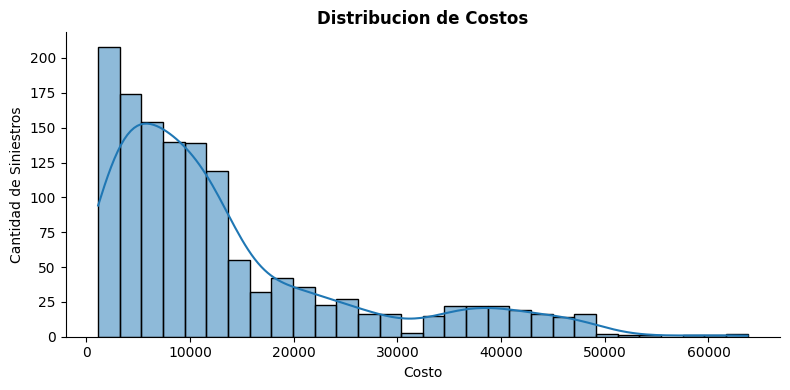

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos un Histograma para ver la distribucion de Charges

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(data=df['charges'], kde=True)

ax.set_title('Distribucion de Costos', fontweight='bold')
ax.set_xlabel('Costo')
ax.set_ylabel('Cantidad de Siniestros')

sns.despine()
plt.tight_layout()
plt.show()

##### Aqui podemos ver que la mayoria de los asegurado generan costos bajos entre 1000 - 10,000. Pero hay una cola larga hacia la derecha con casos muy costosos.

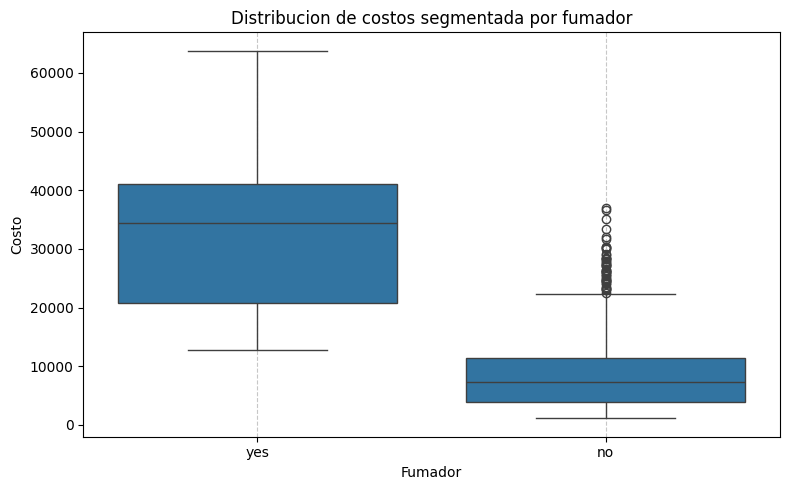

In [52]:
# Creamos un Boxplot para verificar cada grupo y revisar outliers

fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(data=df, x='smoker', y='charges')

ax.set_title('Distribucion de costos segmentada por fumador')
ax.set_xlabel('Fumador')
ax.set_ylabel('Costo')

ax.xaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##### Se puede observar que el grupo que sí fuman le cuestan al seguro entre 3 - 4 veces más en comparación con los que no fuman. La mediana de fumadores está alrededor de 34,000 vs ~8000 para no fumadores. Los outliers de no fumadores pueden estar relacionado con el bmi, ya que un bmi alto puede generar costos elevados por condiciones como diabetes, hipertensión, problemas cardíacos, etc...